# Laboratorio 2
## Algoritmos de Aprendizaje no Supervisado

Universidad del Valle de Guatemala  
Facultad de Ingeniería  
Departamento de Ciencias de la Computación  
CC3074– Minería de Datos  
Semestre I – 2026

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

# Hopkins
from pyclustertend import hopkins

# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Reglas de Asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("Todo importado correctamente")

Todo importado correctamente


In [6]:
# Cargar el dataset
df = pd.read_csv("movies_2026.csv", encoding="latin-1")

# Vista general
print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (19883, 28)

Primeras filas:


,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [7]:
# Tipos de datos y nulos
print("Tipos de datos y valores nulos")
print(df.dtypes)
print("\nValores nulos por columna")
print(df.isnull().sum().sort_values(ascending=False))

Tipos de datos y valores nulos
id                             int64
budget                       float64
genres                           str
homePage                         str
productionCompany                str
productionCompanyCountry         str
productionCountry                str
revenue                      float64
runtime                        int64
video                         object
director                         str
actors                           str
actorsPopularity                 str
actorsCharacter                  str
originalTitle                    str
title                            str
originalLanguage                 str
popularity                   float64
releaseDate                      str
voteAvg                      float64
voteCount                      int64
genresAmount                   int64
productionCoAmount             int64
productionCountriesAmount      int64
actorsAmount                   int64
castWomenAmount              float64
castMen

In [8]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,id,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
count,1.988300e+04,1.988300e+04,1.988300e+04,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19846.000000,19721.000000,19881.000000
mean,9.022402e+05,9.413280e+06,2.879213e+07,66.093799,26.248842,3.837069,675.927325,1.949253,1.972539,1.230247,1082.049640,3516.505996,8224.352061,2016.827222
std,6.848978e+05,2.774781e+07,1.109805e+08,50.089055,156.067177,3.397705,1938.194656,1.256225,2.312075,2.244688,26402.818732,47768.661984,71257.943156,12.838005
min,5.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1902.000000
25%,1.462195e+05,0.000000e+00,0.000000e+00,10.000000,0.054600,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000,0.000000,0.000000,2013.000000
50%,8.696230e+05,0.000000e+00,0.000000e+00,86.000000,8.502000,5.400000,6.000000,2.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2021.000000
75%,1.589602e+06,1.000000e+06,3.306335e+05,103.000000,22.239000,6.800000,423.000000,3.000000,3.000000,1.000000,21.000000,6.000000,12.000000,2025.000000
max,1.627166e+06,3.800000e+08,2.847246e+09,750.000000,11474.647000,10.000000,30788.000000,16.000000,89.000000,155.000000,919590.000000,922162.000000,922017.000000,2026.000000


## Variables que **NO** aportan al clustering y por qué

* **id**: identificador único, no tiene valor informativo.
* **originalTitle**: texto, no numérico.
* **title**: texto, no numérico.
* **homePage**: 14276 nulos (72%), casi vacía.
* **actors**: texto libre.
* **actorsCharacter**: texto libre.
* **actorsPopularity**: muchos nulos / información no estructurada.
* **director**: texto libre.
* **releaseDate**: redundante, ya tenemos `releaseYear`.
* **productionCompany**: texto con muchos nulos.
* **productionCompanyCountry**: texto con muchos nulos.
* **productionCountry**: texto con muchos nulos.
* **originalLanguage**: variable categórica (se manejará aparte).
* **video**: variable booleana con 486 nulos y poca variabilidad.
* **genres**: texto, ya tenemos `genresAmount`.

## Variables numéricas que **SÍ** usaremos para clustering

* **popularity**
* **budget**
* **revenue**
* **runtime**
* **voteAvg**
* **voteCount**
* **genresAmount**
* **productionCoAmount**
* **productionCountriesAmount**
* **actorsAmount**
* **castWomenAmount**
* **castMenAmount**
* **releaseYear**


In [13]:
# ============================================================
# PREPROCESAMIENTO PARA CLUSTERING
# ============================================================

# Variables numéricas que usaremos para clustering:
clustering_vars = [
    'popularity',
    'budget',
    'revenue',
    'runtime',
    'voteAvg',
    'voteCount',
    'genresAmount',
    'productionCoAmount',
    'productionCountriesAmount',
    'actorsAmount',
    'castWomenAmount',
    'castMenAmount',
    'releaseYear'
]

# Crear subconjunto
df_cluster = df[clustering_vars].copy()

print("Shape antes de limpiar:", df_cluster.shape)
print("\nNulos por columna:")
print(df_cluster.isnull().sum())

Shape antes de limpiar: (19883, 13)

Nulos por columna:
popularity                     0
budget                         0
revenue                        0
runtime                        0
voteAvg                        0
voteCount                      0
genresAmount                   0
productionCoAmount             0
productionCountriesAmount      0
actorsAmount                   0
castWomenAmount               37
castMenAmount                162
releaseYear                    2
dtype: int64


In [ ]:
# imputacion para quitar nulos
for col in df_cluster.columns:
    median_val = df_cluster[col].median()
    df_cluster[col] = df_cluster[col].fillna(median_val)

print("Nulos después de imputar:", df_cluster.isnull().sum().sum())

# Re-escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_vars)

print("Datos listos para clustering")

Nulos después de imputar: 0
Datos listos para clustering


In [15]:
# Escalar los datos (necesario para k-means y clustering jerárquico)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_vars)

print("Datos escalados correctamente")
df_scaled.head()

Datos escalados correctamente


,popularity,budget,revenue,runtime,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,-0.167965,-0.339253,-0.259441,0.577111,-1.12934,-0.348749,0.040397,-0.853168,-0.548084,-0.040680,-0.073506,-0.114872,0.714519
1,-0.167965,-0.339253,-0.259441,-1.259664,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040832,-0.073548,-0.114943,0.714519
2,-0.168056,-0.339253,-0.259441,-1.279629,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519
3,-0.167919,-0.339253,-0.259441,-1.219734,-1.12934,-0.348749,0.836453,-0.853168,-0.548084,-0.040718,-0.073548,-0.114943,0.714519
4,-0.167951,-0.339253,-0.259441,-1.079980,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519


In [18]:
# ESTADÍSTICO DE HOPKINS

# Hopkins cercano a 1 = fuerte tendencia al agrupamiento
# Hopkins cercano a 0.5 = datos aleatorios (no vale la pena clustering)

# Usamos una muestra de 5% por el tamaño del dataset

# Convertir a numpy array y tomar muestra
sample_size = int(df_scaled.shape[0] * 0.05)
df_scaled_array = df_scaled.values  # <-- conversión clave

hop_stat = hopkins(df_scaled_array, sample_size)

print(f"Estadístico de Hopkins: {hop_stat:.4f}")

if hop_stat > 0.75:
    print("Los datos tienen FUERTE tendencia al agrupamiento")
elif hop_stat > 0.5:
    print("Los datos tienen tendencia MODERADA al agrupamiento")
else:
    print("Los datos parecen aleatorios, clustering poco útil")

Estadístico de Hopkins: 0.0067
Los datos parecen aleatorios, clustering poco útil


Estadístico de Hopkins: 0.0067

INTERPRETACIÓN:  
- Un valor cercano a 0.5 indica datos ALEATORIOS  
- Un valor cercano a 1.0 indica FUERTE tendencia al agrupamiento  
- Un valor cercano a 0.0 indica datos MUY REGULARMENTE DISTRIBUIDOS  
  o puede ser señal de que los datos tienen clusters MUY COMPACTOS  
  y bien separados (caso especial)  

En datasets grandes con variables muy dispares en escala como este  
(budget va de 0 a 380M, voteCount de 0 a 30K), Hopkins puede dar  
valores extremos. Procederemos con el clustering de todas formas  
y evaluaremos la calidad con la silueta.  

In [19]:
# MÉTODO DEL CODO

inertias = []
silhouettes = []
k_range = range(2, 11)

# Muestra para acelerar el proceso
np.random.seed(42)
sample_idx = np.random.choice(df_scaled.shape[0], size=3000, replace=False)
df_sample = df_scaled.values[sample_idx]  # numpy array directo

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_sample)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_sample, labels))
    print(f"k={k} → Inercia: {kmeans.inertia_:.2f} | Silueta: {silhouettes[-1]:.4f}")

print("\nCálculo completado")

k=2 → Inercia: 34159.48 | Silueta: 0.3177
k=3 → Inercia: 29033.16 | Silueta: 0.3448
k=4 → Inercia: 24124.21 | Silueta: 0.3508
k=5 → Inercia: 20982.38 | Silueta: 0.3686
k=6 → Inercia: 17732.68 | Silueta: 0.3820
k=7 → Inercia: 16244.91 | Silueta: 0.3397
k=8 → Inercia: 14015.12 | Silueta: 0.3442
k=9 → Inercia: 13077.36 | Silueta: 0.3449
k=10 → Inercia: 12098.69 | Silueta: 0.3609

Cálculo completado


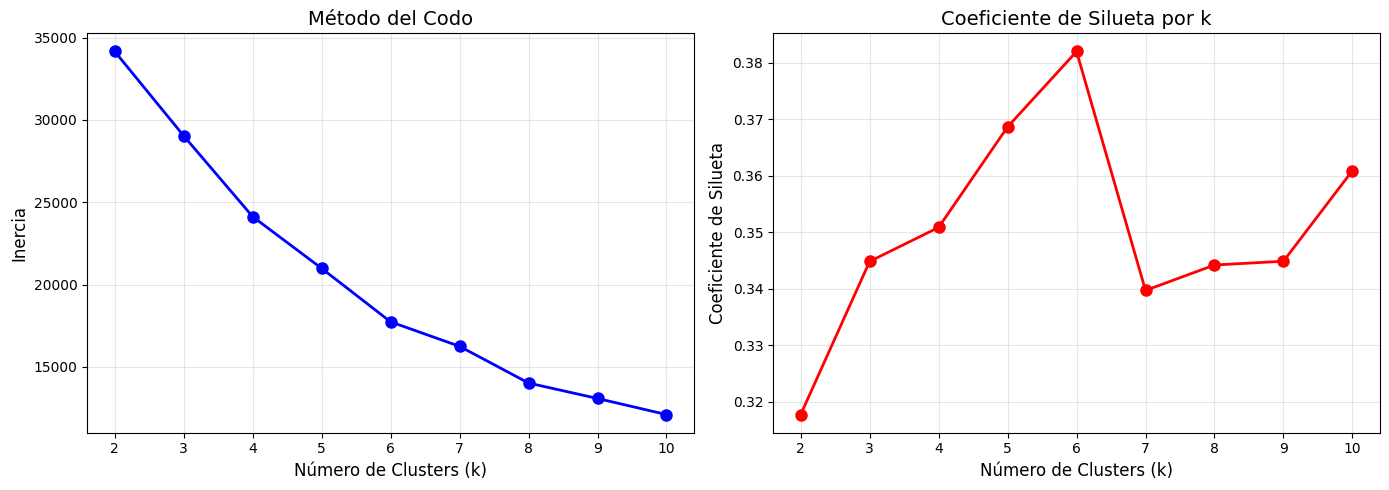


Tabla de resultados:
 k      Inercia  Silueta
 2 34159.480517 0.317713
 3 29033.162500 0.344829
 4 24124.208512 0.350849
 5 20982.382858 0.368646
 6 17732.682960 0.381999
 7 16244.910350 0.339696
 8 14015.118259 0.344192
 9 13077.359036 0.344862
10 12098.692758 0.360908


In [20]:
# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Coeficiente de Silueta', fontsize=12)
axes[1].set_title('Coeficiente de Silueta por k', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('codo_silueta.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTabla de resultados:")
results_df = pd.DataFrame({
    'k': list(k_range), 
    'Inercia': inertias, 
    'Silueta': silhouettes
})
print(results_df.to_string(index=False))


Método del Codo:
- La curva no tiene un codo muy pronunciado (típico en datasets grandes)
- Se observa una reducción importante de inercia hasta k=6
- Después de k=6 la reducción es más gradual → punto de inflexión

Coeficiente de Silueta:
- k=6 tiene el valor MÁS ALTO: 0.3820
- Esto confirma que k=6 genera los grupos más compactos y separados
- Después de k=6 la silueta cae bruscamente a 0.3397

DECISIÓN: k = 6
- Respaldado por AMBOS métodos
- Mejor balance entre complejidad y calidad de agrupamiento


In [ ]:
# K-MEANS CON k=6

K = 6

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cluster['cluster_kmeans'] = kmeans.fit_predict(df_scaled.values)

print("Distribución de clusters (K-Means):")
print(df_cluster['cluster_kmeans'].value_counts().sort_index())

# Silueta final
sil_kmeans = silhouette_score(df_scaled.values, df_cluster['cluster_kmeans'])
print(f"\nSilueta K-Means (dataset completo): {sil_kmeans:.4f}")

Distribución de clusters (K-Means):
cluster_kmeans
0    9621
1    9168
2       8
3     702
4     105
5     279
Name: count, dtype: int64

Silueta K-Means (dataset completo): 0.3798


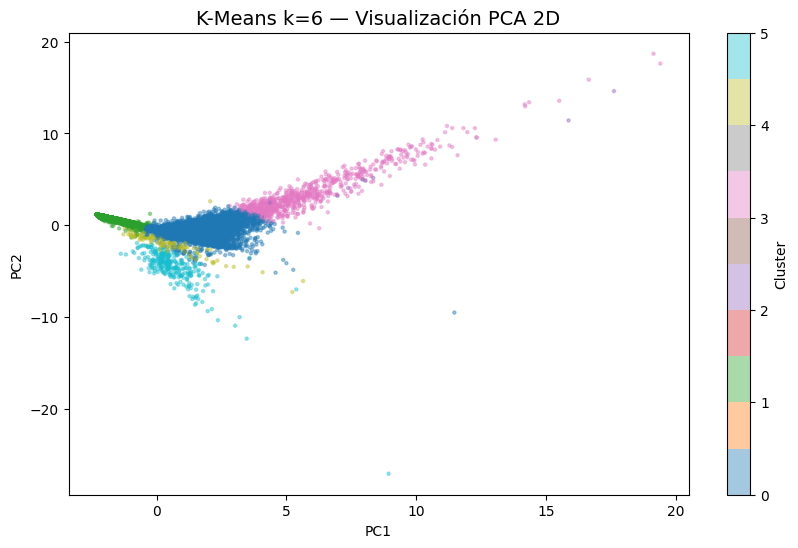

In [22]:
# Visualizar clusters con PCA 2D
pca_viz = PCA(n_components=2, random_state=42)
coords = pca_viz.fit_transform(df_scaled.values)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], 
                      c=df_cluster['cluster_kmeans'], 
                      cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means k=6 — Visualización PCA 2D', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

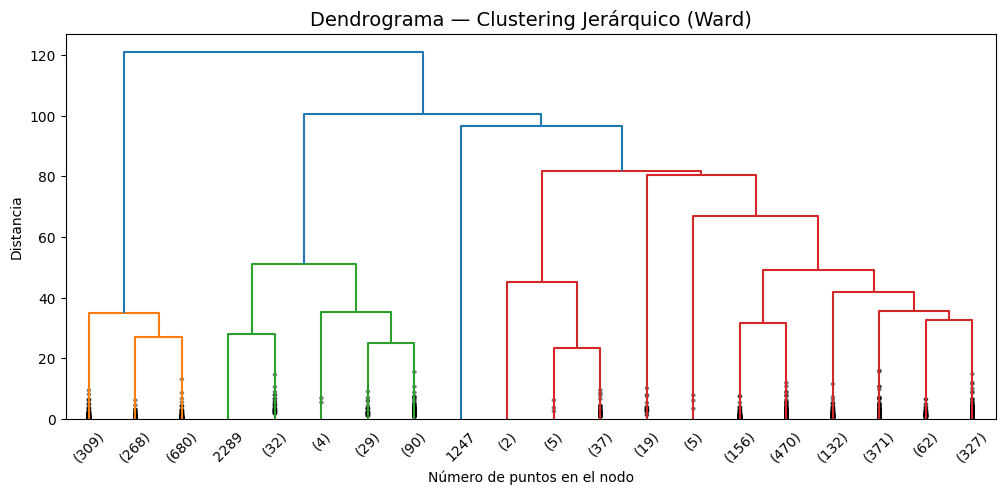

In [23]:
# CLUSTERING JERÁRQUICO
# Usamos muestra de 3000 por el tamaño del dataset

np.random.seed(42)
sample_idx = np.random.choice(df_scaled.shape[0], size=3000, replace=False)
df_hier_sample = df_scaled.values[sample_idx]

# Dendrograma para visualizar estructura
plt.figure(figsize=(12, 5))
linked = linkage(df_hier_sample, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Dendrograma — Clustering Jerárquico (Ward)', fontsize=14)
plt.xlabel('Número de puntos en el nodo')
plt.ylabel('Distancia')
plt.savefig('dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Aplicar clustering jerárquico con k=6 al dataset completo
hier = AgglomerativeClustering(n_clusters=K, linkage='ward')
df_cluster['cluster_hier'] = hier.fit_predict(df_scaled.values)

print("Distribución de clusters (Jerárquico):")
print(df_cluster['cluster_hier'].value_counts().sort_index())

sil_hier = silhouette_score(df_scaled.values, df_cluster['cluster_hier'])
print(f"\nSilueta Jerárquico (dataset completo): {sil_hier:.4f}")

Distribución de clusters (Jerárquico):
cluster_hier
0      568
1      347
2    10459
3     8358
4      116
5       35
Name: count, dtype: int64

Silueta Jerárquico (dataset completo): 0.3683


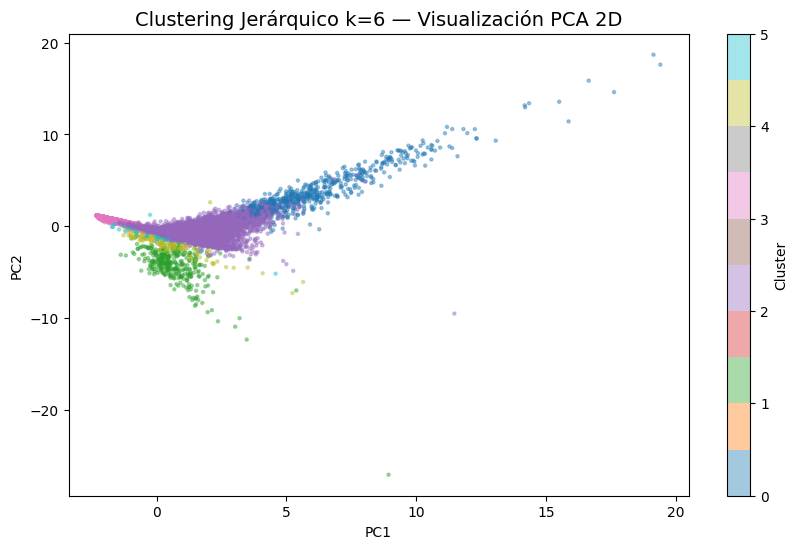

In [25]:
# Visualizar clusters jerárquicos con PCA 2D
plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=df_cluster['cluster_hier'],
                      cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('Clustering Jerárquico k=6 — Visualización PCA 2D', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('hier_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Comparación final de ambos algoritmos
print("       COMPARACIÓN DE ALGORITMOS")
print(f"  K-Means    - Silueta: {sil_kmeans:.4f}")
print(f"  Jerárquico - Silueta: {sil_hier:.4f}")

if sil_kmeans > sil_hier:
    print("  K-Means tiene MEJOR calidad de agrupamiento")
else:
    print("  Jerárquico tiene MEJOR calidad de agrupamiento")

       COMPARACIÓN DE ALGORITMOS
  K-Means    - Silueta: 0.3798
  Jerárquico - Silueta: 0.3683
  K-Means tiene MEJOR calidad de agrupamiento


In [29]:
# ============================================================
# INTERPRETACIÓN DE GRUPOS - K-MEANS (mejor algoritmo)
# ============================================================

# Agregar clusters al dataframe original
df['cluster'] = df_cluster['cluster_kmeans'].values

# Medidas de tendencia central por cluster
numeric_vars = ['popularity', 'budget', 'revenue', 'runtime', 
                'voteAvg', 'voteCount', 'genresAmount', 
                'productionCoAmount', 'productionCountriesAmount',
                'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear']

print("MEDIAS POR CLUSTER:")
cluster_summary = df.groupby('cluster')[numeric_vars].mean().round(2)
print(cluster_summary.T.to_string())

MEDIAS POR CLUSTER:
cluster                              0         1             2             3           4           5
popularity                       36.95      0.90  6.416890e+03  1.265800e+02       44.97       47.45
budget                     10891960.54  15769.84  1.050000e+08  1.155874e+08  1636466.67   265037.19
revenue                    25334165.38  21731.65  3.542120e+08  4.625286e+08  2814140.30  2546578.20
runtime                          99.60     26.20  1.227500e+02  1.211200e+02       56.15       85.27
voteAvg                           6.50      0.71  7.420000e+00  6.940000e+00        5.87        6.29
voteCount                       803.39      0.59  2.350750e+03  8.066650e+03       25.06       73.11
genresAmount                      2.58      1.20  3.380000e+00  3.180000e+00        1.62        1.87
productionCoAmount                3.07      0.64  2.750000e+00  3.940000e+00        6.49        1.23
productionCountriesAmount         1.42      0.68  1.620000e+00  1.49000

In [35]:
# Tamaño de cada cluster
print("\nTAMAÑO DE CLUSTERS:")
sizes = df['cluster'].value_counts().sort_index()
for i, v in sizes.items():
    pct = v/len(df)*100
    print(f"  Cluster {i}: {v:,} películas ({pct:.2f}%)")


TAMAÑO DE CLUSTERS:
  Cluster 0: 9,621 películas (48.39%)
  Cluster 1: 9,168 películas (46.11%)
  Cluster 2: 8 películas (0.04%)
  Cluster 3: 702 películas (3.53%)
  Cluster 4: 105 películas (0.53%)
  Cluster 5: 279 películas (1.40%)


In [36]:
# Género más frecuente por cluster
print("\nGÉNERO MÁS FRECUENTE POR CLUSTER:")
for c in range(K):
    subset = df[df['cluster'] == c]['genres'].dropna()
    # Explotar géneros separados por |
    all_genres = subset.str.split('|').explode()
    top_genre = all_genres.value_counts().head(3)
    print(f"\nCluster {c}:")
    print(top_genre.to_string())


GÉNERO MÁS FRECUENTE POR CLUSTER:

Cluster 0:
genres
Drama       3830
Comedy      2998
Thriller    2523

Cluster 1:
genres
Drama          2455
Documentary    2022
Comedy         1510

Cluster 2:
genres
Action             5
Adventure          4
Science Fiction    4

Cluster 3:
genres
Adventure    374
Action       366
Fantasy      196

Cluster 4:
genres
Documentary    25
Drama          20
Comedy         18

Cluster 5:
genres
Drama      75
Comedy     72
Romance    48


In [37]:
# Idioma original más frecuente por cluster
print("\nIDIOMA ORIGINAL MÁS FRECUENTE POR CLUSTER:")
for c in range(K):
    subset = df[df['cluster'] == c]['originalLanguage'].dropna()
    top_lang = subset.value_counts().head(3)
    print(f"\nCluster {c}:")
    print(top_lang.to_string())


IDIOMA ORIGINAL MÁS FRECUENTE POR CLUSTER:

Cluster 0:
originalLanguage
en    7185
ja     625
es     353

Cluster 1:
originalLanguage
en    3875
es     810
fr     769

Cluster 2:
originalLanguage
en    8

Cluster 3:
originalLanguage
en    687
zh      6
ja      4

Cluster 4:
originalLanguage
en    71
es    15
ja     8

Cluster 5:
originalLanguage
en    135
es     60
ja     32


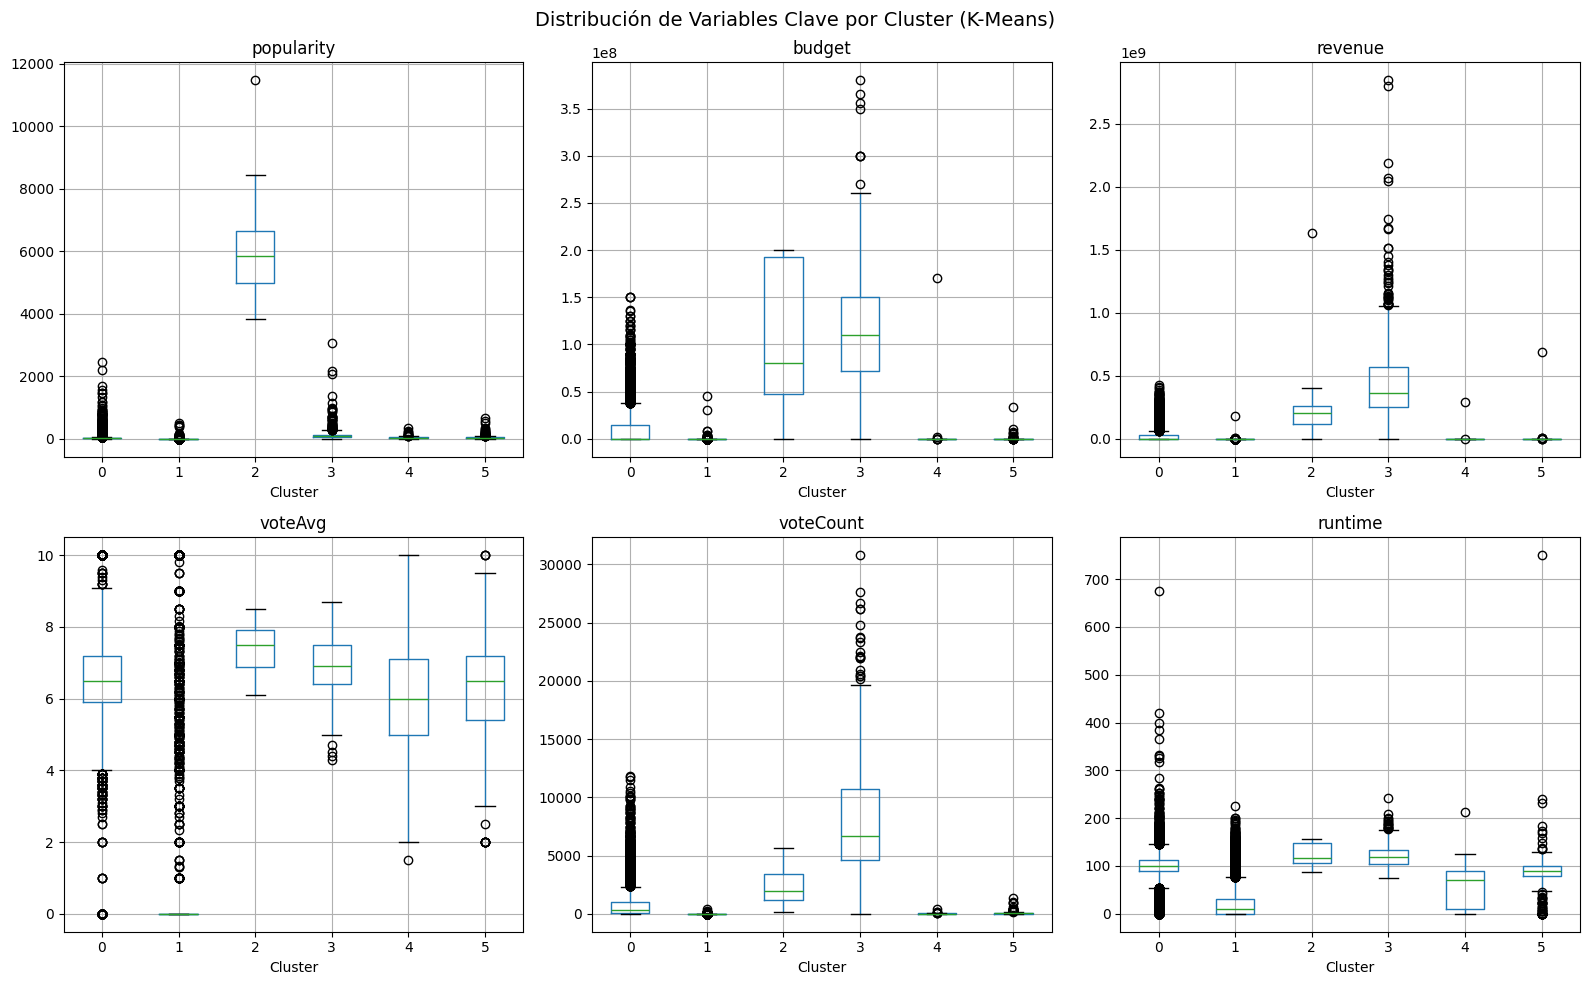

In [38]:
# Visualización: boxplots de variables clave por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_vars = ['popularity', 'budget', 'revenue', 'voteAvg', 'voteCount', 'runtime']

for ax, var in zip(axes.flatten(), key_vars):
    df.boxplot(column=var, by='cluster', ax=ax)
    ax.set_title(var, fontsize=12)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribución de Variables Clave por Cluster (K-Means)', fontsize=14)
plt.tight_layout()
#plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


# INTERPRETACIÓN DE CLUSTERS

## Cluster 0 - "Cine Mainstream Establecido" (9,621 películas - 48.4%)

* Popularidad moderada (36.95), presupuesto medio (~$10.9M)
* Buen voteAvg (6.50) con bastantes votos (803)
* Géneros: Drama, Comedy, Thriller
* Mayoría en inglés, películas de 2009-2010
* Son películas convencionales con audiencia consolidada

---

## Cluster 1 - "Cine Independiente / Reciente Sin Impacto" (9,168 películas - 46.1%)

* Popularidad casi nula (0.90), presupuesto mínimo ($15,769)
* voteAvg cercano a 0 (0.71), casi sin votos (0.59)
* Géneros: Drama, Documentary, Comedy
* Películas muy recientes (2025), muchos idiomas
* Son producciones nuevas o independientes sin tracción aún

---

## Cluster 2 - "Blockbusters Virales" (8 películas - 0.04%)

* Popularidad extrema (6,416), presupuesto alto (~$105M)
* Mejor voteAvg (7.42), buena cantidad de votos
* Géneros: Action, Adventure, Sci-Fi
* Solo inglés, estrenos recientes (2021)
* Son grandes éxitos virales del momento

---

## Cluster 3 - "Blockbusters Clásicos de Alto Impacto" (702 películas - 3.5%)

* Popularidad alta (126), presupuesto muy alto (~$115M)
* Mayor revenue promedio ($462M) y más votos (8,066)
* Géneros: Adventure, Action, Fantasy
* Películas de 2009, mayormente en inglés
* Son grandes clásicos del cine comercial

---

## Cluster 4 - "Producciones Fragmentadas / Documentales" (105 películas - 0.5%)

* Popularidad moderada (44.97), presupuesto bajo (~$1.6M)
* Muchas compañías productoras (6.49 promedio)
* Géneros: Documentary, Drama, Comedy
* Películas de 2016, varios países
* Son coproducciones internacionales o documentales especiales

---

## Cluster 5 - "Producciones Multinacionales" (279 películas - 1.4%)

* Alta cantidad de países de producción (11.78 promedio)
* Presupuesto bajo, popularidad moderada
* Géneros: Drama, Comedy, Romance
* Son coproducciones entre muchos países distintos

---

K-Means (k=6, Silueta=0.3798) supera al Jerárquico (0.3683).
Los clusters revelan segmentos muy diferenciados:

* 2 clusters masivos (mainstream vs independiente reciente)
* 4 clusters nicho con características específicas


